# OpenTouch Dataset Exploration
## 6.S985 Project — Direction B: Pre-Contact Intent Prediction from Gaze and Trajectory

This notebook provides structured exploration of the OpenTouch dataset with a focus on Direction B:
predicting grasp intent from pre-contact egocentric video and hand trajectory — before touch occurs.

### HDF5 Structure (confirmed)
```
file.hdf5
└── data/
    ├── demo_00/
    │   ├── rgb_images_jpeg       (T,)        JPEG-encoded bytes
    │   ├── right_pressure        (T, 16, 16) tactile pressure map
    │   ├── right_hand_landmarks  (T, 21, 3)  full hand joints
    │   ├── right_palm_pos        (T, 3)      palm position
    │   ├── right_wrist_pos       (T, 3)      wrist position
    │   ├── camera_poses          (T, 4, 4)   extrinsic camera pose
    │   └── timestamps            (T,)        unix timestamps
    ├── demo_01/ ...
    └── ...
```

### Contents
1. Imports & paths
2. Dataset inventory
3. Annotations loading
4. Modality visualization
5. Contact onset detection
6. Pre-contact window extraction
7. Label distributions
8. Pre-contact trajectory analysis
9. Dataset-wide index & train/val/test split

---
## 1. Imports & Paths

In [1]:
import os
import io
import json
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# ── Paths: adjust OPENTOUCH_ROOT to your local clone ──────────────────────
OPENTOUCH_ROOT = Path('/Users/cassandrahe/Documents/6.S985/opentouch')
DATA_DIR        = OPENTOUCH_ROOT / 'data'
ANNOTATIONS_DIR = DATA_DIR / 'final_annotations'

assert DATA_DIR.exists(), f'DATA_DIR not found: {DATA_DIR}'
assert ANNOTATIONS_DIR.exists(), f'ANNOTATIONS_DIR not found: {ANNOTATIONS_DIR}'
print('Paths OK')

Paths OK


---
## 2. Dataset Inventory

In [2]:
hdf5_files = sorted(DATA_DIR.glob('*.hdf5'))
print(f'Found {len(hdf5_files)} HDF5 files\n')

# Each file has a top-level 'data' group containing demo_00, demo_01, ...
file_demo_map = {}  # Path -> list of demo keys
total_clips = 0

for hf in hdf5_files:
    with h5py.File(hf, 'r') as f:
        if 'data' not in f:
            print(f'  WARNING: no data group in {hf.name}')
            continue
        demos = sorted(f['data'].keys())
        file_demo_map[hf] = demos
        total_clips += len(demos)

print(f'{"File":<40} {"Clips":>6}')
print('-' * 48)
for hf, demos in file_demo_map.items():
    print(f'{hf.name:<40} {len(demos):>6}')
print('-' * 48)
print(f'{"Total clips":<40} {total_clips:>6}')

Found 26 HDF5 files

File                                      Clips
------------------------------------------------
eat_mcdonalds.hdf5                           51
eat_ygf_p1.hdf5                              14
eat_ygf_p2.hdf5                              44
fablab_ml_p1.hdf5                            86
fablab_ml_p2.hdf5                            94
fablab_ml_p3.hdf5                            47
grocery_plant.hdf5                           70
grocery_target_p1.hdf5                      134
grocery_target_p2.hdf5                       98
grocery_target_p3.hdf5                      227
grocery_tj.hdf5                              77
hardware_homedepot_p1.hdf5                   29
hardware_homedepot_p2.hdf5                  101
hardware_homedepot_p3.hdf5                  135
hardware_homedepot_p4.hdf5                   95
hardware_homedepot_p5.hdf5                  184
home_bedroom.hdf5                           138
home_kitchen_p1.hdf5                        190
home_kitchen_p2.hd

Clip length (frames) — mean: 110.6, median: 85, min: 17, max: 1381


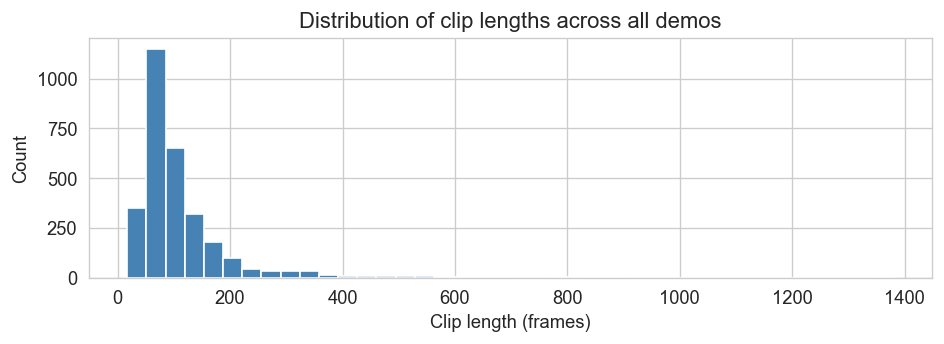

In [3]:
# Clip length distribution
clip_lengths = []
for hf, demos in file_demo_map.items():
    with h5py.File(hf, 'r') as f:
        for demo_id in demos:
            T = f['data'][demo_id]['timestamps'].shape[0]
            clip_lengths.append(T)

clip_lengths = np.array(clip_lengths)
print(f'Clip length (frames) — mean: {clip_lengths.mean():.1f}, '
      f'median: {np.median(clip_lengths):.0f}, '
      f'min: {clip_lengths.min()}, max: {clip_lengths.max()}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(clip_lengths, bins=40, color='steelblue', edgecolor='white')
ax.set_xlabel('Clip length (frames)')
ax.set_ylabel('Count')
ax.set_title('Distribution of clip lengths across all demos')
plt.tight_layout()
plt.show()

---
## 3. Annotations

In [4]:
# Inspect what is in the annotations directory
ann_files = list(ANNOTATIONS_DIR.iterdir())
print(f'Files in annotations dir ({len(ann_files)} total):')
for f in sorted(ann_files)[:20]:
    print(f'  {f.name}')
if len(ann_files) > 20:
    print(f'  ... and {len(ann_files) - 20} more')

Files in annotations dir (25 total):
  eat_mcdonalds_merged.csv
  eat_ygf_p1_merged.csv
  eat_ygf_p2_merged.csv
  fablab_ml_p1_merged.csv
  fablab_ml_p2_merged.csv
  fablab_ml_p3_merged.csv
  grocery_plant_merged.csv
  grocery_target_p1_merged.csv
  grocery_target_p2_merged.csv
  grocery_target_p3_p4_merged_by_ts_merged.csv
  grocery_tj_merged.csv
  hardware_homedepot_p1_merged.csv
  hardware_homedepot_p2_merged.csv
  hardware_homedepot_p3_merged.csv
  hardware_homedepot_p4_merged.csv
  hardware_homedepot_p5_merged.csv
  home_bedroom_merged.csv
  home_kitchen_p1_merged.csv
  home_kitchen_p2_merged.csv
  home_kitchen_p3_merged.csv
  ... and 5 more


In [5]:
def load_annotations(annotations_dir):
    """
    Load OpenTouch annotations into a dataframe.
    Handles a single combined JSON, per-file JSONs, or CSVs.
    """
    ann_dir = Path(annotations_dir)
    records = []

    csv_files  = sorted(ann_dir.glob('*.csv'))
    json_files = sorted(ann_dir.glob('*.json'))

    if csv_files:
        dfs = [pd.read_csv(f) for f in csv_files]
        df = pd.concat(dfs, ignore_index=True)
        print(f'Loaded {len(df)} rows from {len(csv_files)} CSV file(s)')
        return df

    if json_files:
        for jf in json_files:
            with open(jf) as f:
                data = json.load(f)
            if isinstance(data, list):
                records.extend(data)
            elif isinstance(data, dict):
                for k, v in data.items():
                    if isinstance(v, dict):
                        v['demo_id'] = k
                        records.append(v)
                    elif isinstance(v, list):
                        records.extend(v)
        df = pd.DataFrame(records)
        print(f'Loaded {len(df)} rows from {len(json_files)} JSON file(s)')
        return df

    print('No JSON or CSV files found in annotations dir.')
    return None

annotations = load_annotations(ANNOTATIONS_DIR)
if annotations is not None:
    print(f'Columns: {list(annotations.columns)}')
    display(annotations.head())

Loaded 2958 rows from 25 CSV file(s)
Columns: ['clip_id', 'object_name', 'object_category', 'environment', 'action', 'grip_type', 'description', 'ts_start', 'ts_end', 'model', 'onset_idx', 'onset_ts', 'peak_idx', 'peak_ts', 'post_idx', 'post_ts']


,clip_id,object_name,object_category,environment,action,grip_type,description,ts_start,ts_end,model,onset_idx,onset_ts,peak_idx,peak_ts,post_idx,post_ts
0,eat_mcdonalds::demo_00,soft-serve ice cream cone,snack,restaurant,holding,Small Diameter,A small vanilla soft‑serve cone with a white s...,706282194387,716147279137,gpt-5,9,706582147762,12,706682133475,210,713281075262
1,eat_mcdonalds::demo_01,plastic drink cup,cup,restaurant,picking up,Small Diameter,A small transparent plastic cup holding a dark...,718846848137,720413268687,gpt-5,28,719780037562,41,720213301012,46,720379941387
2,eat_mcdonalds::demo_02,plastic drink cup with lid and straw,drinkware,restaurant,placing,Medium Wrap,A clear plastic cold-drink cup with a flat lid...,723379457437,725745751387,gpt-5,3,723479447512,9,723679414312,42,724779237725
3,eat_mcdonalds::demo_03,drinking straw,utensil,restaurant,inserting,Tip Pinch,A narrow white straw is held above a lidded fo...,725345808975,728012050187,gpt-5,54,727145527137,75,727845408137,79,727978722887
4,eat_mcdonalds::demo_04,paper straw wrapper,paper,restaurant,removing,Tip Pinch,"At a small table in a fast‑food restaurant, th...",727712098850,729345168100,gpt-5,0,727712098850,4,727845408137,31,728745262887


---
## 4. Modality Visualization

In [6]:
def load_clip(hdf5_path, demo_id):
    """
    Load all modalities for one clip. Decodes JPEG frames to numpy arrays.
    """
    data = {}
    with h5py.File(hdf5_path, 'r') as f:
        clip = f['data'][demo_id]

        jpeg_frames = clip['rgb_images_jpeg'][()]
        rgb_frames = [np.array(Image.open(io.BytesIO(bytes(j)))) for j in jpeg_frames]
        data['rgb']        = np.stack(rgb_frames)                      # (T, H, W, 3)
        data['pressure']   = clip['right_pressure'][()]                # (T, 16, 16)
        data['landmarks']  = clip['right_hand_landmarks'][()]          # (T, 21, 3)
        data['palm_pos']   = clip['right_palm_pos'][()]                # (T, 3)
        data['wrist_pos']  = clip['right_wrist_pos'][()]               # (T, 3)
        data['timestamps'] = clip['timestamps'][()]                    # (T,)
    return data

# Load the first clip from the first file
sample_file = list(file_demo_map.keys())[0]
sample_demo = file_demo_map[sample_file][0]
print(f'Loading: {sample_file.name} / {sample_demo} ...')
clip = load_clip(sample_file, sample_demo)

print('\nLoaded modalities:')
for k, v in clip.items():
    print(f'  {k}: {v.shape} {v.dtype}')

Loading: eat_mcdonalds.hdf5 / demo_00 ...

Loaded modalities:
  rgb: (297, 480, 640, 3) uint8
  pressure: (297, 16, 16) float32
  landmarks: (297, 21, 3) float64
  palm_pos: (297, 3) float64
  wrist_pos: (297, 3) float64
  timestamps: (297,) int64


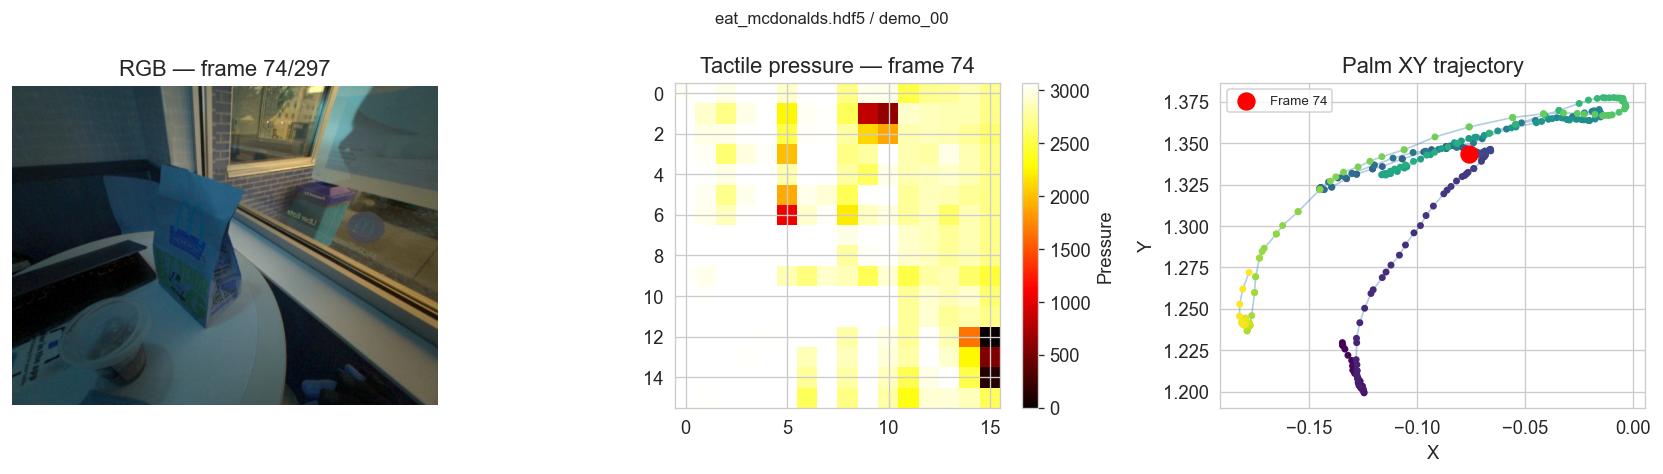

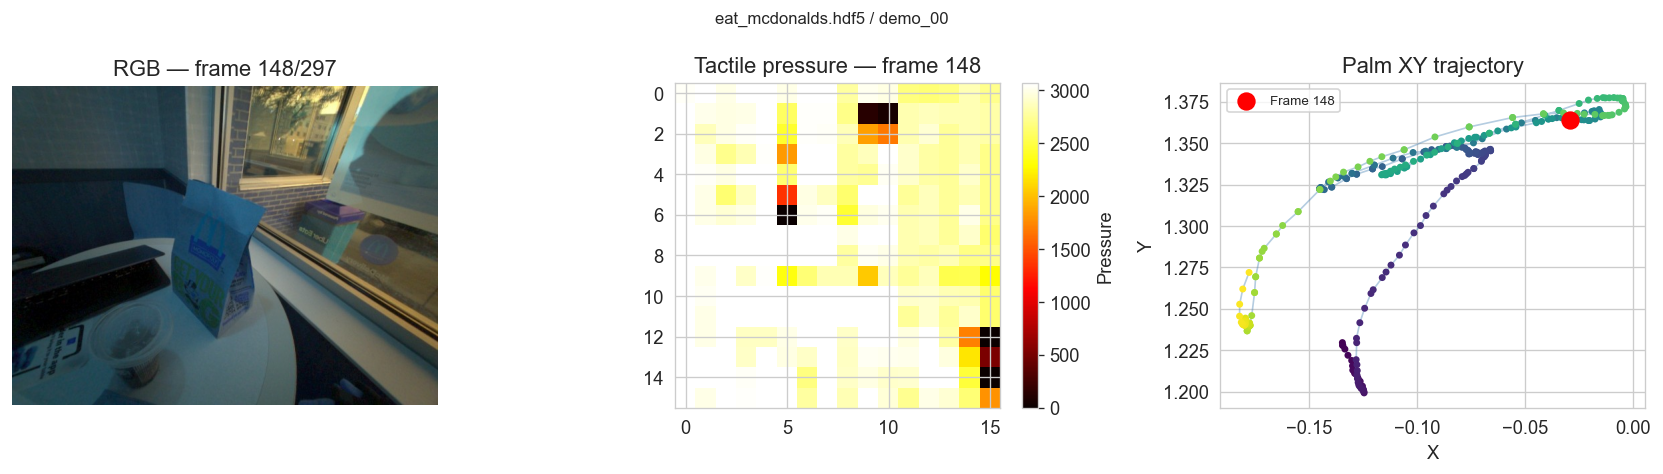

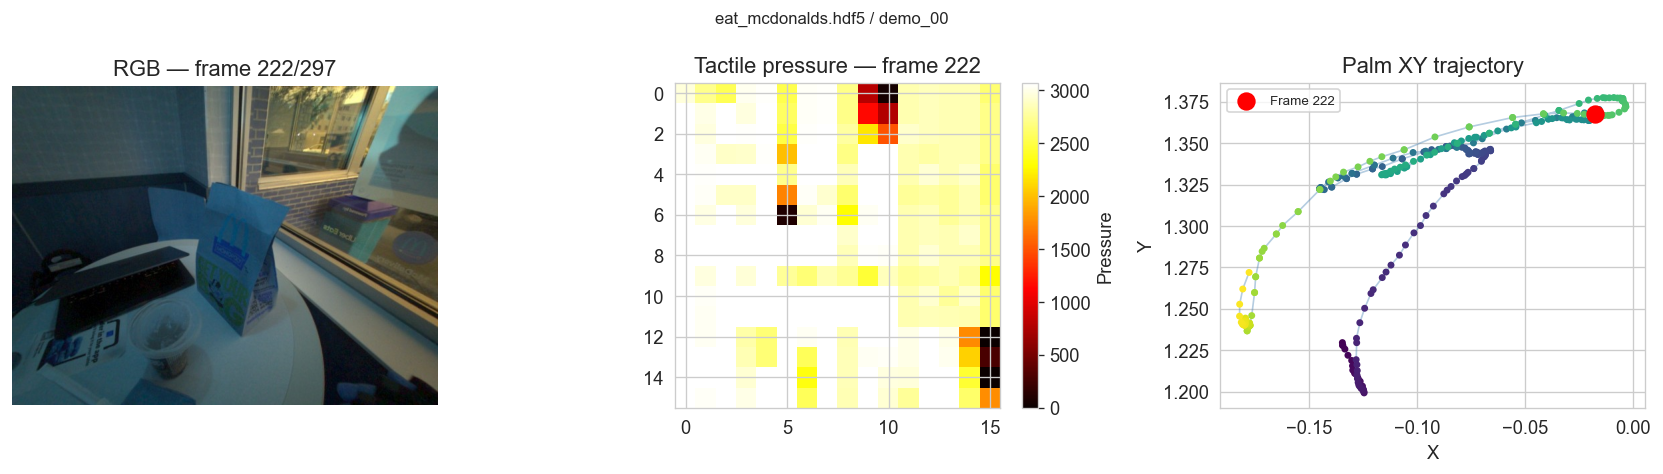

In [7]:
def visualize_frame(clip, frame_idx, title=''):
    """Visualize RGB, tactile pressure, and palm trajectory for one frame."""
    T = len(clip['timestamps'])
    frame_idx = min(frame_idx, T - 1)

    fig = plt.figure(figsize=(14, 4))
    gs  = gridspec.GridSpec(1, 3, figure=fig)

    # RGB
    ax1 = fig.add_subplot(gs[0])
    ax1.imshow(clip['rgb'][frame_idx])
    ax1.set_title(f'RGB — frame {frame_idx}/{T}')
    ax1.axis('off')

    # Tactile
    ax2 = fig.add_subplot(gs[1])
    im = ax2.imshow(clip['pressure'][frame_idx], cmap='hot',
                    vmin=0, vmax=max(clip['pressure'].max(), 1e-6))
    plt.colorbar(im, ax=ax2, fraction=0.046, label='Pressure')
    ax2.set_title(f'Tactile pressure — frame {frame_idx}')

    # Palm XY trajectory
    ax3 = fig.add_subplot(gs[2])
    palm = clip['palm_pos']
    ax3.plot(palm[:, 0], palm[:, 1], color='steelblue', alpha=0.4, linewidth=1)
    ax3.scatter(palm[:, 0], palm[:, 1], c=np.arange(T), cmap='viridis', s=10, zorder=3)
    ax3.scatter(palm[frame_idx, 0], palm[frame_idx, 1],
                c='red', s=100, zorder=5, label=f'Frame {frame_idx}')
    ax3.set_title('Palm XY trajectory')
    ax3.set_xlabel('X')
    ax3.set_ylabel('Y')
    ax3.legend(fontsize=8)

    plt.suptitle(title or f'{sample_file.name} / {sample_demo}', fontsize=10)
    plt.tight_layout()
    plt.show()

T = len(clip['timestamps'])
for idx in [T // 4, T // 2, 3 * T // 4]:
    visualize_frame(clip, idx)

---
## 5. Contact Onset Detection

In [25]:
def detect_contact_onset(pressure, rise_factor=3.0, min_frames=3):
    """
    Detect onset as the first frame where pressure exceeds
    baseline + rise_factor * baseline_std.
    More robust than a fixed threshold when baseline is non-zero.
    """
    max_p = pressure.reshape(len(pressure), -1).max(axis=1)
    
    # Estimate baseline from first 10 frames
    baseline = max_p[:10].mean()
    baseline_std = max_p[:10].std() + 1e-6
    
    threshold = baseline + rise_factor * baseline_std
    above = max_p > threshold
    
    for i in range(len(above) - min_frames + 1):
        if above[i:i + min_frames].all():
            return i
    return None

def plot_pressure_timeline(pressure, onset_frame=None, title='Tactile pressure over time'):
    flat  = pressure.reshape(len(pressure), -1)
    max_p = flat.max(axis=1)
    mean_p = flat.mean(axis=1)
    if max_p.max() > 0:
        max_p  = max_p  / max_p.max()
        mean_p = mean_p / (mean_p.max() + 1e-9)

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(max_p,  label='Max pressure',  color='firebrick', linewidth=1.5)
    ax.plot(mean_p, label='Mean pressure', color='steelblue', linewidth=1.5, alpha=0.8)
    if onset_frame is not None:
        ax.axvline(onset_frame, color='orange', linestyle='--',
                   linewidth=2, label=f'Contact onset (frame {onset_frame})')
        ax.axvspan(0, onset_frame, alpha=0.08, color='green', label='Pre-contact window')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Normalized pressure')
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

Find a good clip:


Clip: eat_mcdonalds.hdf5 / demo_01
Onset: frame 28 / 48 | Peak: 41 | Action: picking up | Grip: Small Diameter


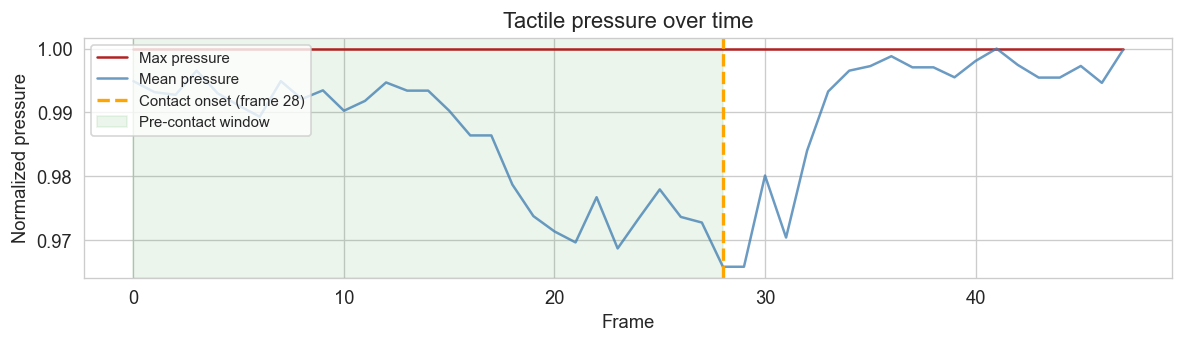

In [26]:
# Pick a clip with a good pre-contact window for visualization
good = index[index['onset_idx'] >= 20].iloc[0]
sample_file = Path(good['hdf5_path'])
sample_demo = good['demo_id']
onset = good['onset_idx']

clip = load_clip(sample_file, sample_demo)
T = len(clip['timestamps'])
print(f'Clip: {sample_file.name} / {sample_demo}')
print(f'Onset: frame {onset} / {T} | Peak: {good["peak_idx"]} | Action: {good["action"]} | Grip: {good["grip_type"]}')
plot_pressure_timeline(clip['pressure'], onset_frame=onset)

In [22]:
print(annotations.head(10)[['clip_id', 'action', 'grip_type', 
                              'onset_idx', 'peak_idx', 'post_idx']].to_string())
print(f'\nonset_idx stats:')
print(annotations['onset_idx'].describe())

                  clip_id      action           grip_type  onset_idx  peak_idx  post_idx
0  eat_mcdonalds::demo_00     holding      Small Diameter          9        12       210
1  eat_mcdonalds::demo_01  picking up      Small Diameter         28        41        46
2  eat_mcdonalds::demo_02     placing         Medium Wrap          3         9        42
3  eat_mcdonalds::demo_03   inserting           Tip Pinch         54        75        79
4  eat_mcdonalds::demo_04    removing           Tip Pinch          0         4        31
5  eat_mcdonalds::demo_05   inserting  Prismatic 2 Finger         36        45        52
6  eat_mcdonalds::demo_06  picking up         Medium Wrap          0         9        73
7  eat_mcdonalds::demo_07     holding      Small Diameter          3         5       107
8  eat_mcdonalds::demo_08    grasping           Tip Pinch          5        11        21
9  eat_mcdonalds::demo_09   unfolding           Tip Pinch          0         0        20

onset_idx stats:
cou

---
## 6. Pre-Contact Window Extraction

Pre-contact window: frames 0 to 28 (28 frames)


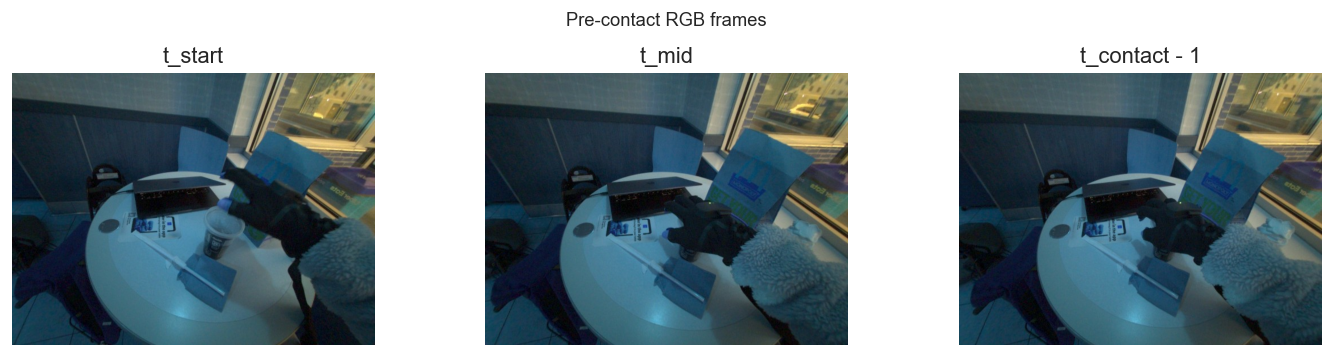

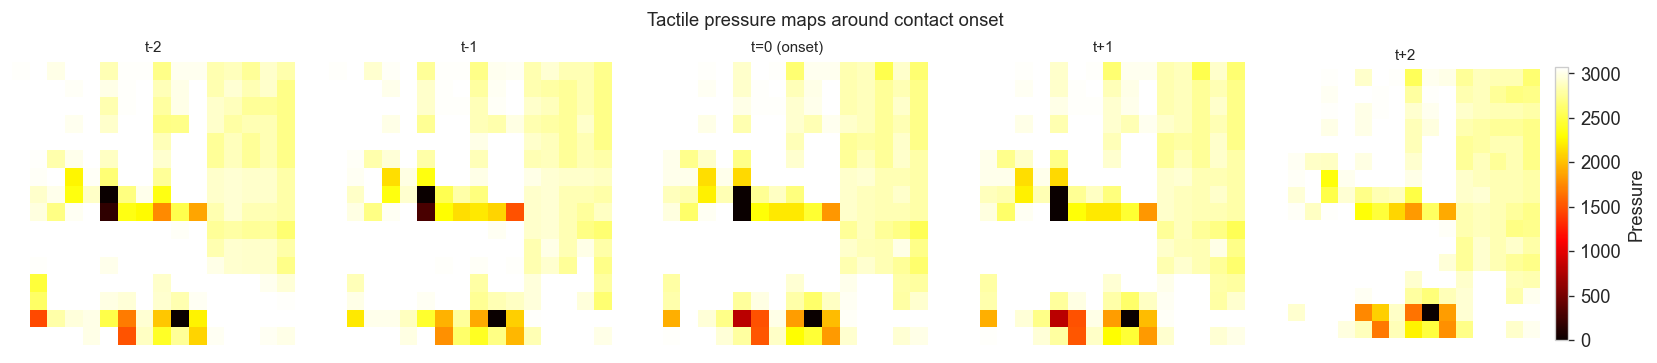

In [44]:
def extract_precontact_window(clip, onset_frame, window_frames=30):
    start = max(0, onset_frame - window_frames)
    window = {k: v[start:onset_frame] for k, v in clip.items()
              if isinstance(v, np.ndarray)}
    return window, start, onset_frame

# Ensure onset is an int from annotations
onset = int(good['onset_idx'])
T = len(clip['timestamps'])

# if onset is not None and onset >= 5:
# onset is now set directly from annotations — no detection needed
window, win_start, win_end = extract_precontact_window(clip, onset, window_frames=30)
print(f'Pre-contact window: frames {win_start} to {win_end} ({len(window["rgb"])} frames)')

# Show RGB strip: first, mid, last pre-contact frame
n = len(window['rgb'])
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, idx, label in zip(axes, [0, n // 2, n - 1],
                        ['t_start', 't_mid', 't_contact - 1']):
    ax.imshow(window['rgb'][idx])
    ax.set_title(label)
    ax.axis('off')
plt.suptitle('Pre-contact RGB frames', fontsize=11)
plt.tight_layout()
plt.show()

# Tactile maps around contact onset
indices = [max(0, onset-2), max(0, onset-1), onset,
        min(T-1, onset+1), min(T-1, onset+2)]
labels  = ['t-2', 't-1', 't=0 (onset)', 't+1', 't+2']
p_max   = clip['pressure'].max()
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for ax, idx, label in zip(axes, indices, labels):
    im = ax.imshow(clip['pressure'][idx], cmap='hot', vmin=0, vmax=p_max)
    ax.set_title(label, fontsize=9)
    ax.axis('off')
plt.colorbar(im, ax=axes[-1], fraction=0.046, label='Pressure')
plt.suptitle('Tactile pressure maps around contact onset', fontsize=11)
plt.tight_layout()
plt.show()
# else:
    # print('Onset too early or not detected — try a different clip.')

---
## 7. Label Distributions

Annotation columns: ['clip_id', 'object_name', 'object_category', 'environment', 'action', 'grip_type', 'description', 'ts_start', 'ts_end', 'model', 'onset_idx', 'onset_ts', 'peak_idx', 'peak_ts', 'post_idx', 'post_ts']
Likely label columns: ['action', 'grip_type']


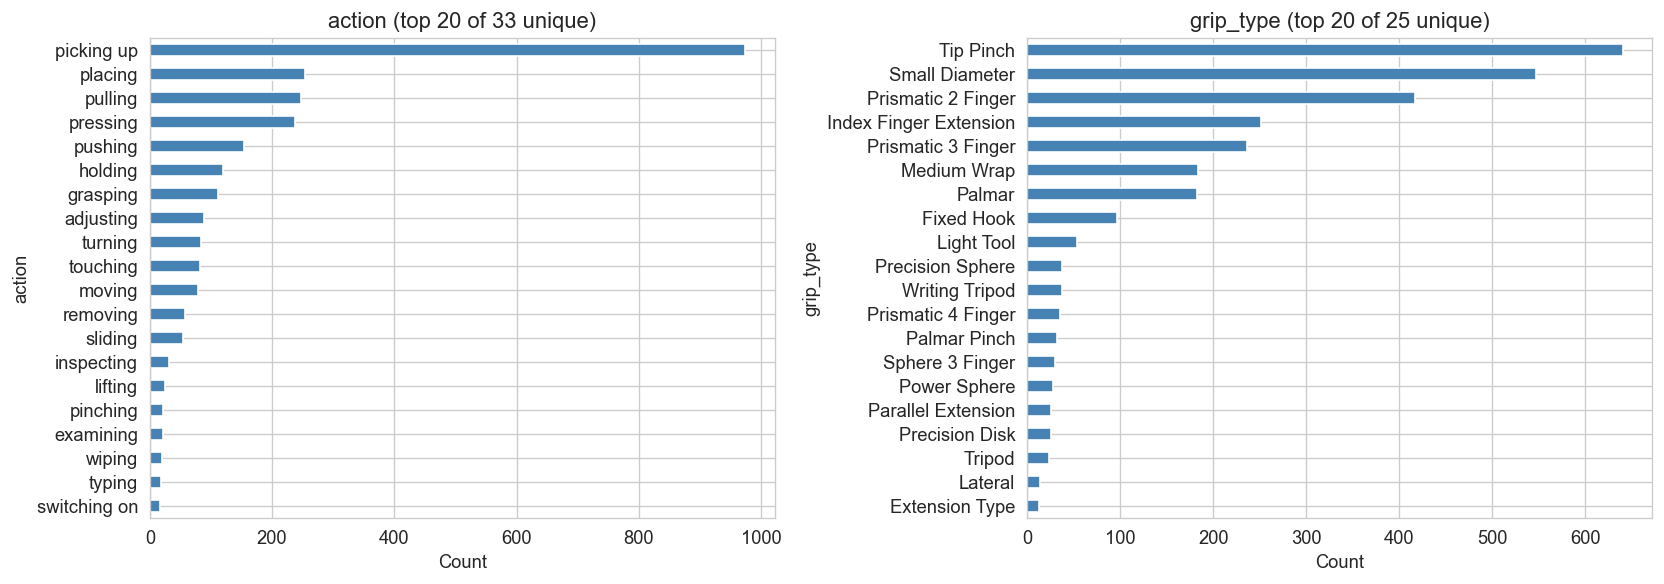

In [35]:
if annotations is not None and len(annotations) > 0:
    print('Annotation columns:', list(annotations.columns))
    label_cols = [c for c in annotations.columns
                  if any(k in c.lower() for k in ['action', 'grip', 'grasp', 'label'])]
    print('Likely label columns:', label_cols)

    if label_cols:
        fig, axes = plt.subplots(1, len(label_cols),
                                  figsize=(7 * len(label_cols), 5))
        if len(label_cols) == 1:
            axes = [axes]
        for ax, col in zip(axes, label_cols):
            counts = annotations[col].value_counts()
            counts.head(20).plot(kind='barh', ax=ax, color='steelblue')
            ax.set_title(f'{col} (top 20 of {counts.nunique()} unique)')
            ax.set_xlabel('Count')
            ax.invert_yaxis()
        plt.tight_layout()
        plt.show()
else:
    print('No annotations loaded. Check ANNOTATIONS_DIR.')

In [46]:
# Object category distribution
print('Object category distribution:')
print(annotations['object_category'].value_counts().to_string())
print()

# onset_idx window length broken down by grip type
print('Pre-contact window length (onset_idx) by grip type:')
print(annotations.groupby('grip_type')['onset_idx'].describe()[
    ['count', 'mean', 'std', 'min', '50%', 'max']
].round(1).to_string())
print()

# Grip types most affected by short pre-contact windows
insufficient = annotations[annotations['onset_idx'] < 5]['grip_type'].value_counts()
total = annotations['grip_type'].value_counts()
pct = (insufficient / total * 100).round(1)
summary = pd.DataFrame({'short_window_count': insufficient, 
                        'total': total, 
                        'pct_short': pct}).dropna()
print('Grip types with most clips having onset_idx < 5:')
print(summary.sort_values('pct_short', ascending=False).to_string())

Object category distribution:
object_category
handle                     231
hand tool                  133
container                  112
utensil                    111
bottle                     108
sports equipment           106
packaged food              103
cleaning item               82
toy                         79
button                      77
knob                        74
clothing item               64
chair                       63
bag                         58
hardware                    55
can                         52
ball                        50
construction material       48
fruit                       48
paper                       47
box                         46
drawer                      40
power tool                  35
measuring tool              34
appliance                   33
plant                       32
package                     31
light                       30
fastener                    30
vegetable                   29
book                    

---
## 8. Pre-Contact Trajectory Analysis

The three signals below are the core inputs for Direction B intent prediction:
- **Palm approach** (Z depth decreasing toward object)
- **Palm XY path** (spatial approach trajectory)
- **Fingertip spread** (grasp preshaping — different grip types will show different spreading patterns)

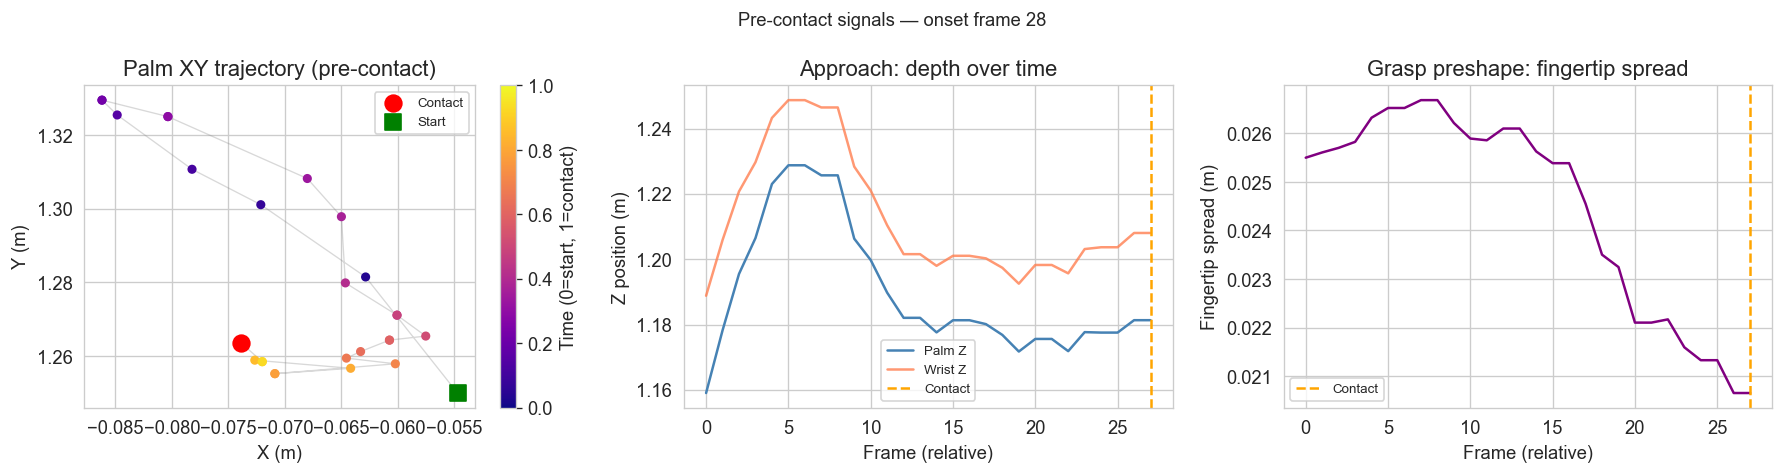

In [45]:
def plot_precontact_trajectory(clip, onset_frame, window_frames=30):
    start = max(0, onset_frame - window_frames)
    palm   = clip['palm_pos'][start:onset_frame]
    wrist  = clip['wrist_pos'][start:onset_frame]
    lm     = clip['landmarks'][start:onset_frame]  # (W, 21, 3)
    W = len(palm)
    t = np.linspace(0, 1, W)

    fig = plt.figure(figsize=(15, 4))
    gs  = gridspec.GridSpec(1, 3, figure=fig)

    # Palm XY trajectory
    ax1 = fig.add_subplot(gs[0])
    sc = ax1.scatter(palm[:, 0], palm[:, 1], c=t, cmap='plasma', s=20, zorder=3)
    ax1.plot(palm[:, 0], palm[:, 1], alpha=0.3, color='gray', linewidth=0.8)
    ax1.scatter(*palm[-1, :2], c='red',   s=100, zorder=5, label='Contact')
    ax1.scatter(*palm[0,  :2], c='green', s=100, zorder=5, label='Start', marker='s')
    plt.colorbar(sc, ax=ax1, label='Time (0=start, 1=contact)')
    ax1.set_title('Palm XY trajectory (pre-contact)')
    ax1.set_xlabel('X (m)')
    ax1.set_ylabel('Y (m)')
    ax1.legend(fontsize=8)

    # Palm Z approach
    ax2 = fig.add_subplot(gs[1])
    ax2.plot(palm[:, 2],  label='Palm Z',  color='steelblue', linewidth=1.5)
    ax2.plot(wrist[:, 2], label='Wrist Z', color='coral',     linewidth=1.5, alpha=0.8)
    ax2.axvline(W - 1, color='orange', linestyle='--', linewidth=1.5, label='Contact')
    ax2.set_xlabel('Frame (relative)')
    ax2.set_ylabel('Z position (m)')
    ax2.set_title('Approach: depth over time')
    ax2.legend(fontsize=8)

    # Fingertip spread (grasp preshape)
    ax3 = fig.add_subplot(gs[2])
    fingertip_idx = [4, 8, 12, 16, 20]  # MediaPipe fingertip landmarks
    fingertips = lm[:, fingertip_idx, :]         # (W, 5, 3)
    spread = fingertips.std(axis=1).mean(axis=1) # mean std across XYZ
    ax3.plot(spread, color='purple', linewidth=1.5)
    ax3.axvline(W - 1, color='orange', linestyle='--', linewidth=1.5, label='Contact')
    ax3.set_xlabel('Frame (relative)')
    ax3.set_ylabel('Fingertip spread (m)')
    ax3.set_title('Grasp preshape: fingertip spread')
    ax3.legend(fontsize=8)

    plt.suptitle(f'Pre-contact signals — onset frame {onset_frame}', fontsize=11)
    plt.tight_layout()
    plt.show()

plot_precontact_trajectory(clip, onset_frame=onset)

---
## 9. Dataset-Wide Index & Train/Val/Test Split

In [31]:
def build_precontact_index(annotations, min_precontact_frames=5):
    """
    Build index of usable clips using onset_idx from annotations.
    Filters to clips with at least min_precontact_frames before onset.
    """
    records = []
    
    for _, row in annotations.iterrows():
        # Parse clip_id: "eat_mcdonalds::demo_00"
        parts = row['clip_id'].split('::')
        if len(parts) != 2:
            continue
        hdf5_stem, demo_id = parts
        
        onset = int(row['onset_idx'])
        if onset < min_precontact_frames:
            continue
        
        # Find matching HDF5 file
        matching = [hf for hf in hdf5_files if hf.stem == hdf5_stem]
        if not matching:
            continue
        hdf5_path = matching[0]
        
        records.append({
            'hdf5_path':    str(hdf5_path),
            'demo_id':      demo_id,
            'environment':  hdf5_stem,
            'onset_idx':    onset,
            'peak_idx':     int(row['peak_idx']),
            'post_idx':     int(row['post_idx']),
            'action':       row['action'],
            'grip_type':    row['grip_type'],
            'object_name':  row['object_name'],
            'object_category': row['object_category'],
        })
    
    return pd.DataFrame(records)

index = build_precontact_index(annotations, min_precontact_frames=5)
print(f'Usable clips (onset >= 5 frames): {len(index)} / {len(annotations)}')
print(f'\nGrip type distribution:')
print(index['grip_type'].value_counts().to_string())
print(f'\nAction distribution:')
print(index['action'].value_counts().to_string())

# print('Building pre-contact index (this may take a minute)...')
# index = build_precontact_index(file_demo_map, annotations)
# print(f'\nUsable clips: {len(index)} / {sum(len(v) for v in file_demo_map.values())}')
# index.head()

Usable clips (onset >= 5 frames): 1344 / 2958

Grip type distribution:
grip_type
Tip Pinch                 288
Small Diameter            228
Prismatic 2 Finger        192
Index Finger Extension    126
Palmar                     99
Prismatic 3 Finger         96
Medium Wrap                84
Fixed Hook                 43
Light Tool                 31
Writing Tripod             24
Precision Sphere           16
Precision Disk             15
Parallel Extension         14
Prismatic 4 Finger         14
Lateral                    11
Power Sphere               10
Tripod                      9
Palmar Pinch                9
Ventral                     9
Sphere 3 Finger             6
Adducted Thumb              5
Power Disk                  5
Extension Type              5
Ring                        3
Tripod Variation            2

Action distribution:
action
picking up       310
placing          172
pressing         126
pulling          117
pushing           83
holding           59
grasping      

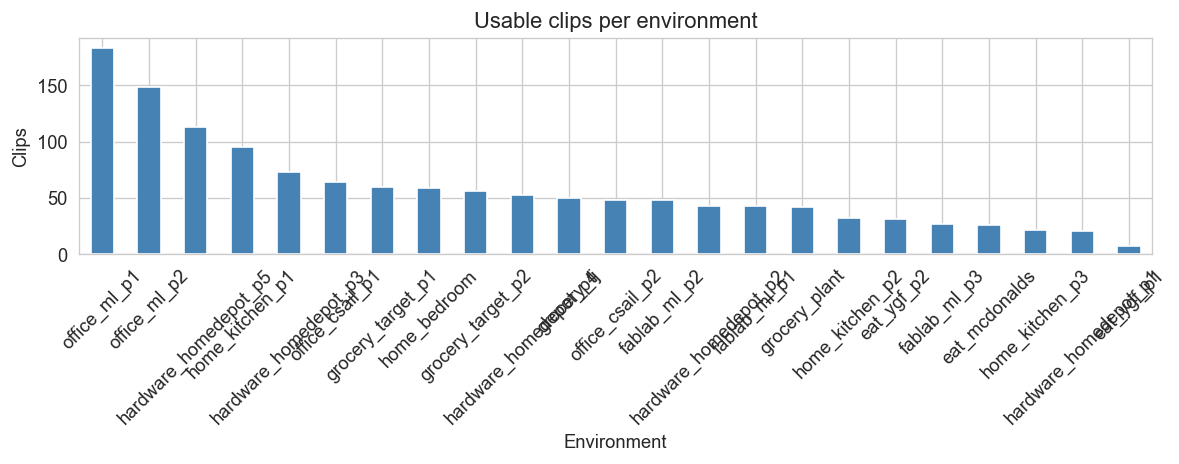

In [32]:
# Environment distribution of usable clips
fig, ax = plt.subplots(figsize=(10, 4))
index['environment'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Usable clips per environment')
ax.set_xlabel('Environment')
ax.set_ylabel('Clips')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [33]:
# Group rare grip types into 'Other' to avoid stratification failures
min_samples = 20
counts = index['grip_type'].value_counts()
rare = counts[counts < min_samples].index
index['grip_type_grouped'] = index['grip_type'].apply(
    lambda x: 'Other' if x in rare else x)

print('Grouped grip type distribution:')
print(index['grip_type_grouped'].value_counts().to_string())
print(f'\nClasses kept: {index["grip_type_grouped"].nunique()}')

Grouped grip type distribution:
grip_type_grouped
Tip Pinch                 288
Small Diameter            228
Prismatic 2 Finger        192
Other                     133
Index Finger Extension    126
Palmar                     99
Prismatic 3 Finger         96
Medium Wrap                84
Fixed Hook                 43
Light Tool                 31
Writing Tripod             24

Classes kept: 11


In [34]:
from sklearn.model_selection import train_test_split

label_cols = [c for c in index.columns
              if c.startswith('label_') and c not in ['label_demo_id', 'label_clip_id']]

if label_cols:
    stratify_col = label_cols[0]
    labeled = index[index[stratify_col].notna()].copy()
    print(f'Stratifying on: {stratify_col} ({labeled[stratify_col].nunique()} classes)')
    train_val, test = train_test_split(
        labeled, test_size=0.15, stratify=labeled[stratify_col], random_state=42)
    train, val = train_test_split(
        train_val, test_size=0.15/0.85, stratify=train_val[stratify_col], random_state=42)
else:
    print('No label columns found — splitting without stratification')
    train_val, test = train_test_split(index, test_size=0.15, random_state=42)
    train, val      = train_test_split(train_val, test_size=0.15/0.85, random_state=42)

print(f'Train: {len(train)} | Val: {len(val)} | Test: {len(test)}')

out_dir = DATA_DIR / 'splits'
out_dir.mkdir(exist_ok=True)
train.to_csv(out_dir / 'train.csv', index=False)
val.to_csv(out_dir   / 'val.csv',   index=False)
test.to_csv(out_dir  / 'test.csv',  index=False)
print(f'Splits saved to {out_dir}')

No label columns found — splitting without stratification
Train: 940 | Val: 202 | Test: 202
Splits saved to /Users/cassandrahe/Documents/6.S985/opentouch/data/splits


---
## Summary

### What this notebook established
- **Dataset scale**: 26 HDF5 files, 2,958 annotated clips across 14 environments and 100+ object categories
- **Modalities confirmed**: RGB (JPEG-encoded), tactile pressure (16×16), hand landmarks (21 joints × 3D), palm/wrist position, timestamps
- **Pre-contact windows**: 1,344 usable clips (45.4%) after filtering to onset_idx ≥ 5
- **Gaze data**: not available in HDF5 files or annotations
- **Key finding**: fingertip spread decreases monotonically in the ~15 frames before contact, reflecting anticipatory grip preshaping before touch
- **Label imbalance**: 3 grip types (Sphere 4 Finger, Large Diameter, Lateral Tripod) have no usable pre-contact windows; dominant classes lose ~45-50% of clips after filtering
- **Object diversity**: 100+ object categories dominated by handles, hand tools, containers, and utensils
- **Splits**: saved to `data/splits/`

### Results
Classification ablation experiments (visual / visual+pose / visual+pose+tactile) are documented in `experiments/direction_B/`.